In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

# Style settings
plt.rcParams['figure.facecolor'] = '#0f0f1a'
plt.rcParams['axes.facecolor'] = '#161625'
plt.rcParams['axes.edgecolor'] = '#2a2a3a'
plt.rcParams['text.color'] = '#e0e0f0'
plt.rcParams['axes.labelcolor'] = '#e0e0f0'
plt.rcParams['xtick.color'] = '#9999aa'
plt.rcParams['ytick.color'] = '#9999aa'
plt.rcParams['grid.color'] = '#2a2a3a'
plt.rcParams['grid.alpha'] = 0.5
plt.rcParams['font.family'] = 'monospace'
plt.rcParams['font.size'] = 11

# Color palettes
BURNOUT_COLORS  = {'Low': '#6af7c8', 'Medium': '#f7c56a', 'High': '#f76a8a'}
STRESS_COLORS   = {'Low': '#6af7c8', 'Medium': '#f7c56a', 'High': '#f76a8a'}
GENDER_COLORS   = {'Male': '#7c6af7', 'Female': '#f76a8a', 'Other': '#6af7c8'}
SLEEP_COLORS    = {'Good': '#6af7c8', 'Average': '#f7c56a', 'Poor': '#f76a8a'}
COURSE_COLORS   = ['#7c6af7','#f76a8a','#6af7c8','#f7c56a','#a78bfa','#fb923c']

print('Libraries loaded successfully!')
print('Ready for analysis...')

Libraries loaded successfully!
Ready for analysis...


In [3]:
df = pd.read_csv("student_mental_health_burnout.csv")
df.head()

,student_id,age,gender,course,year,daily_study_hours,daily_sleep_hours,screen_time_hours,stress_level,anxiety_score,depression_score,academic_pressure_score,financial_stress_score,social_support_score,physical_activity_hours,sleep_quality,attendance_percentage,cgpa,internet_quality,burnout_level
0,100001,23,Male,BTech,1st,4.3,6.8,6.1,High,10,3,4,2,6,1.8,Average,66.5,9.63,Good,High
1,100002,20,Male,BTech,3rd,1.4,4.7,3.0,High,2,10,8,5,9,1.9,Poor,55.8,6.04,Poor,Low
2,100003,24,Female,BCA,4th,3.7,4.8,1.5,Low,2,7,8,6,3,0.8,Good,85.0,8.31,Good,High
3,100004,21,Male,BSc,4th,1.6,6.7,7.0,High,3,3,4,9,9,0.7,Poor,89.1,5.95,Good,High
4,100005,23,Other,BSc,4th,2.0,6.7,5.4,High,7,7,6,4,4,1.7,Good,58.7,8.51,Good,Low


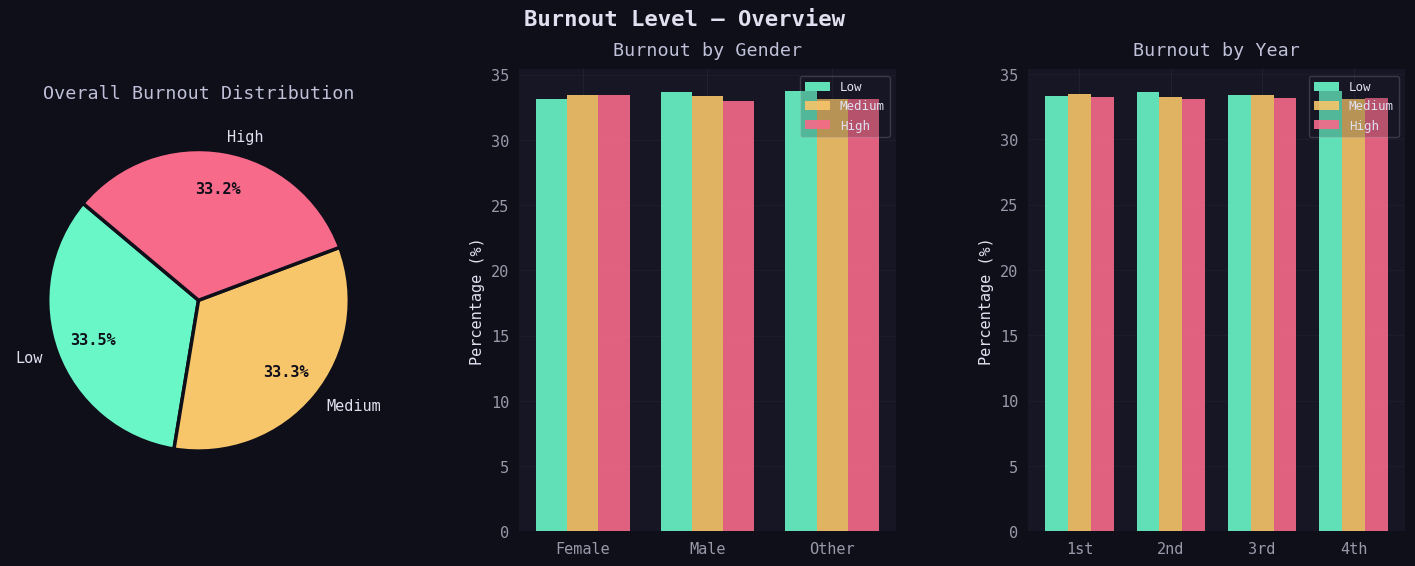

In [4]:
fig = plt.figure(figsize=(18, 6))
fig.suptitle('Burnout Level — Overview', fontsize=16, fontweight='bold', color='#e0e0f0')
gs = GridSpec(1, 3, figure=fig, wspace=0.35)

# --- Pie chart ---
ax1 = fig.add_subplot(gs[0])
burnout_counts = df['burnout_level'].value_counts()
colors_pie = [BURNOUT_COLORS[k] for k in burnout_counts.index]
wedges, texts, autotexts = ax1.pie(
    burnout_counts, labels=burnout_counts.index, colors=colors_pie,
    autopct='%1.1f%%', startangle=140, pctdistance=0.75,
    wedgeprops={'linewidth': 2.5, 'edgecolor': '#0f0f1a'}
)
for t in autotexts: t.set_color('#0f0f1a'); t.set_fontsize(11); t.set_fontweight('bold')
ax1.set_title('Overall Burnout Distribution', color='#c0c0d8', pad=10)

# --- Bar by gender ---
ax2 = fig.add_subplot(gs[1])
burnout_gender = df.groupby(['gender','burnout_level']).size().unstack(fill_value=0)
burnout_gender_pct = burnout_gender.div(burnout_gender.sum(axis=1), axis=0) * 100
x = np.arange(len(burnout_gender_pct))
w = 0.25
for i, level in enumerate(['Low','Medium','High']):
    ax2.bar(x + i*w, burnout_gender_pct[level], w, label=level,
            color=BURNOUT_COLORS[level], alpha=0.9, edgecolor='none')
ax2.set_xticks(x + w)
ax2.set_xticklabels(burnout_gender_pct.index)
ax2.set_ylabel('Percentage (%)')
ax2.set_title('Burnout by Gender', color='#c0c0d8', pad=10)
ax2.legend(framealpha=0.2, fontsize=9)
ax2.grid(axis='y', alpha=0.3)
ax2.spines[['top','right','left','bottom']].set_visible(False)

# --- Bar by year ---
ax3 = fig.add_subplot(gs[2])
burnout_year = df.groupby(['year','burnout_level']).size().unstack(fill_value=0)
order = ['1st','2nd','3rd','4th']
burnout_year = burnout_year.reindex(order)
burnout_year_pct = burnout_year.div(burnout_year.sum(axis=1), axis=0) * 100
x = np.arange(len(burnout_year_pct))
for i, level in enumerate(['Low','Medium','High']):
    ax3.bar(x + i*w, burnout_year_pct[level], w, label=level,
            color=BURNOUT_COLORS[level], alpha=0.9, edgecolor='none')
ax3.set_xticks(x + w)
ax3.set_xticklabels(order)
ax3.set_ylabel('Percentage (%)')
ax3.set_title('Burnout by Year', color='#c0c0d8', pad=10)
ax3.legend(framealpha=0.2, fontsize=9)
ax3.grid(axis='y', alpha=0.3)
ax3.spines[['top','right','left','bottom']].set_visible(False)

# plt.savefig('02_burnout_overview.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()